# PINN Model Using Literature Data
This model uses **experimental data from Zhou et al. (2025)**. 

# Imports

In [330]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
from scipy.stats import lognorm, weibull_min, genextreme, kstest
import torch
import torch.nn as nn

# 1. Input Parameters
collects all inputs from experimental data and literature

## 1.1. Literature Data
*Data from* Zhou, S., Henrich, M., Wei, Z., Feng, F., Yang, B., & Münstermann, S. (2025). A general physics-informed neural network framework for fatigue life prediction of metallic materials. Engineering Fracture Mechanics, 322, 111136.

In [331]:
cleaned_sheets = pd.read_excel("/Users/jessiekreinsen/pinn-project/data/zhou/data_zhou_cleaned.xlsx", sheet_name=None)

with open("/Users/jessiekreinsen/pinn-project/data/zhou/data_zhou_metadata.json", "r") as f:
    metadata = json.load(f)

datasets = {}

for sheet_name, df in cleaned_sheets.items():
    datasets[sheet_name] = metadata[sheet_name]
    datasets[sheet_name]["data"] = df

In [332]:
# find Ti-6Al-4V datasets
ti_datasets = []

for name, info in datasets.items():
    material = info["material"].lower()

    if "ti" in material and "6" in material:
        ti_datasets.append(name)

        print(name)
        print("  material:", info["material"])
        print("  category:", info["category"])
        print("  columns:", info["columns"])

Case Ti-6.5Al-2Zr-Mo-V
  material: Ti-6.5Al-2Zr-Mo-V
  category: defect_informed
  columns: ['stress_max', 'sqrt_A_um', 'defect_position_um', 'Nf']


In [333]:
# select one Ti dataset
dataset_name = ti_datasets[0]

df_raw = datasets[dataset_name]["data"].copy()

print(f"Using dataset:, {dataset_name}")
print(df_raw.head())

Using dataset:, Case Ti-6.5Al-2Zr-Mo-V
   stress_max  sqrt_A_um  defect_position_um      Nf
0         720          4                 315  875322
1         720          7                 594  627590
2         720         12                 960  375137
3         720         37                 204  804089
4         720         38                 953  777717


### 1.1.a. Data Cleaning

In [334]:
# confirm no missing values
print("\nMissing values:")
print(df_raw.isnull().sum())

print(f"\nShape: {df_raw.shape}")
print(df_raw.describe())


Missing values:
stress_max            0
sqrt_A_um             0
defect_position_um    0
Nf                    0
dtype: int64

Shape: (30, 4)
       stress_max   sqrt_A_um  defect_position_um             Nf
count   30.000000   30.000000           30.000000      30.000000
mean   750.666667   57.033333          690.700000  404141.366667
std     30.954175   35.177857          450.019858  246361.024663
min    720.000000    4.000000           66.000000   29930.000000
25%    720.000000   37.000000          284.000000  217148.250000
50%    760.000000   51.500000          628.500000  378331.000000
75%    760.000000   82.250000          999.000000  558817.000000
max    800.000000  132.000000         1631.000000  891389.000000


There are no missing values! Continue safetly.

In [335]:
df = df_raw.copy()

In [336]:
# convert all columns to numeric where possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="ignore")

/var/folders/p1/96qjs4ks4h55rkkznq_8stfr0000gn/T/ipykernel_17326/1823320844.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


In [337]:
print(df.columns.tolist())

['stress_max', 'sqrt_A_um', 'defect_position_um', 'Nf']


### 1.1.b. Data Extraction

In [338]:
# find available inputs and outputs from dataset
candidate_features = [
    "stress_max",
    "stress_a",
    "deltaK",
    "Kt",       # stress concentration factors
    "sqrt_A_um_um",
    "sqrt_A_m",
    "defect_size_um",
    "defect_position_um",
    "l_leff",
    "Nf"
]

features = [c for c in candidate_features if c in df.columns]

print("Available features:", features)

Available features: ['stress_max', 'defect_position_um', 'Nf']


In [339]:
# pull columns into numpy arrays for modeling
stress_max = df["stress_max"].to_numpy()
sqrt_A_um = df["sqrt_A_um"].to_numpy(dtype=float)
defect_position_um = df["defect_position_um"].to_numpy(dtype=float)
Nf = df["Nf"].to_numpy(dtype=float)

In [340]:
# # add column with converted √area, [micrometers] to area/crack size [m]
# df["a_max"] = (sqrt_A_um * 1e-6)**2           # a = area

# # pull column into numpy arrays for modeling
# a_max = df["a_max"].to_numpy()

In [341]:
# clean valid positive values
sqrt_A_um = sqrt_A_um[np.isfinite(sqrt_A_um)]
sqrt_A_um = sqrt_A_um[sqrt_A_um > 0]

# convert to meters if needed
sqrt_A_m = sqrt_A_um * 1e-6

## 1.2. Material Parameters
Paris law constants, fracture toughness, threshold SIF

Paris–Erdogan law:  **da/dN = C · ΔK^m**
- valid for  K_th < ΔK < K_c  (Stage II crack growth)

In [342]:
# C, m depend on material

# for name, info in datasets.items():
#     material = info["material"].lower()

if "ti" in material and "6" in material:
    ti_datasets.append(name)

    # print(name)
    print("  material:", info["material"])
    print("  category:", info["category"])
    print("  columns:", info["columns"])

  material: Ti-6.5Al-2Zr-Mo-V
  category: defect_informed
  columns: ['stress_max', 'sqrt_A_um', 'defect_position_um', 'Nf']


In [343]:
# for Ti6Al4V from LPBF
C_Ti = 0.76899e-7     # Paris constant [m/cycle / (MPa√m)^m]
m_Ti = 2.56492        # Paris exponent

# for SLM 316l
C_SLM = 7.0e-15
m_SLM = 6.0

if "ti" in material and "6" in material:
    C = C_Ti
    m = m_Ti
    print(f"Paris law: da/dN = {C_Ti:.2e} * deltaK^{m_Ti}")

elif "slm" in material:
    C = C_Ti
    m = m_Ti
    print(f"Paris law: da/dN = {C_SLM:.2e} * deltaK^{m_SLM}")
else:
    print("C and m are unknown.")

Paris law: da/dN = 7.69e-08 * deltaK^2.56492


*For Paris constants, C and m, for SLM:*
Kluczynski, J. et al. (2020). Crack Growth Behavior of Additively Manufactured 316L Steel—Influence of Build Orientation and Heat Treatment. *Materials*. MDPI. DOI:10.3390/ma13153259

*For Paris constants, C and m, for Ti6Al4V from LPBF:*
Wang, H. et al. (2022). Fatigue performance at ultra-low porosity of Ti6Al4V produced by laser powder bed fusion after post heat treatment. *SSRN Electronic Journal*. <https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4224194>.

## 1.3. Geometry Parameters
specimen dimensions, defect location (→ Y factor)

In [344]:
# specimen dimensions: assume cylinderical gauge section, A = π * (d/2)^2
h = 50e-3               # height [m]
d = 10e-3               # diameter [m]
A = np.pi * (d/2)**2    # cross-sectional area [m^2]

V_gauge = A * h                # gauge volume [m^3]
V_gauge_mm3 = V_gauge * 1e9    # [mm^3] for display

print(f"Gauge volume V = {V_gauge_mm3:.1f} mm^3")

Gauge volume V = 3927.0 mm^3


Specimen dimensions given by Zhou et al. (2025); assumed cylindrical.

**Note:** Specimen dimensions are not necessary in this model.

In [345]:
# define a function to classify defects by position
def classify_defect_position(pos_um, threshold_um=200):
    if pos_um <= threshold_um:
        return "surface/subsurface"
    else:
        return "internal"

# create defect class column
df["defect_class"] = df["defect_position_um"].apply(
    lambda x: classify_defect_position(x, threshold_um=200)
)

# create geometry correction factor Y column
df["Y"] = df["defect_class"].map({
    "surface/subsurface": 0.65,
    "internal": 0.50
})

# pull column into numpy arrays for modeling
Y = df["Y"].to_numpy()

print(df[["defect_position_um", "Y"]].head())
print(df["Y"].value_counts())

   defect_position_um    Y
0                 315  0.5
1                 594  0.5
2                 960  0.5
3                 204  0.5
4                 953  0.5
Y
0.50    27
0.65     3
Name: count, dtype: int64


The defect position is used to find the geometric correction factor where Y = 0.5 for internal defects and Y = 0.65 for surface and subsurface defects, given a 200-micrometer threshold.

## 1.4. Loading Parameters
stress amplitude, mean stress, frequency

frequency, R given in Zhou et al. (2025)

In [346]:
stress_max = df["stress_max"]             # max stress [MPa]
freq = 30       # cyclic frequency [Hz]
R = 0.1
stress_min = R * stress_max
#stress_a = (stress_max - stress_min) / 2    
stress_a = ((1 - R) / 2) * stress_max     # stress amplitude [MPa]

# Effective stress range:
    # crack faces close under compression, no damage contribution
delta_sigma = stress_max - stress_min

*For the stress amplitude equation*: Zhang, Z., & Xu, Z. (2023). Fatigue database of additively manufactured alloys. Scientific Data, 10, 249. https://doi.org/10.1038/s41597-023-02150-x

# 2. Defect Size Distribution
Through fracture mechanics and the Paris law, the critical defect size controls the fatigue life.

This section will present a parametric PDF fit to measured defect sizes

## 2.2. Defect Size Distribution
Since Zhou reports √A, this data is treated as the **critical defect**.

The distribution of the defects is fitted and plotted.

### 2.2.a. Distribution Parameters
Since the Zhou dataset directly reports the critical defect size √A, the distribution parameters are estimated **directly from the experimental √A values** rather than from a VED-based synthetic model.

In [347]:
# distribution parameters fitted directly from experimental √area data
sqrt_A_um_valid = sqrt_A_um[np.isfinite(sqrt_A_um) & (sqrt_A_um > 0)]

# lognormal parameters from measured √area [μm]
sigma_ln, loc_ln, scale_ln = lognorm.fit(sqrt_A_um_valid, floc=0)

mu_ln = np.log(scale_ln)
median_sqrt_A = np.exp(mu_ln)

print("Experimental defect-size distribution parameters:")
print(f"  mu_ln = {mu_ln:.4f}")
print(f"  sigma_ln = {sigma_ln:.4f}")
print(f"  median √A = {median_sqrt_A:.2f} μm")

Experimental defect-size distribution parameters:
  mu_ln = 3.7800
  sigma_ln = 0.8408
  median √A = 43.82 μm


### 2.2.b. Fit Parametric PDF
Three candidate distributions are fitted by MLE.

The best distribution is selected by the lowest Kolmogorov–Smirnov statistic.

In [348]:
# define a function to fit a parametric distribution to the defect sizes by MLE
def fit_distribution(sizes, dist_name):
    # lognormal distribution
    if dist_name == "lognormal":
        s, loc, scale = lognorm.fit(sizes, floc=0)
        frozen = lognorm(s=s, loc=0, scale=scale)
        params = {"mu_ln": np.log(scale), "sigma_ln": s}

    # Weibull distribution (3-parameter, with loc fixed at 0)
    elif dist_name == "Weibull":
        k, loc, scale = weibull_min.fit(sizes, floc=0)
        frozen = weibull_min(c=k, loc=0, scale=scale)
        params = {"k": k, "lambda": scale}

    # Gumbel distribution (for maxima, with loc and scale)
    elif dist_name == "Gumbel":
        from scipy.stats import gumbel_r
        loc, scale = gumbel_r.fit(sizes)
        frozen = gumbel_r(loc=loc, scale=scale)
        params = {"loc": loc, "scale": scale}

    else:
        raise ValueError(f"Unknown distribution: {dist_name!r}")

    ks_stat, ks_p = kstest(sizes, frozen.cdf)
    return frozen, ks_stat, ks_p, params

# fit each candidate distribution
data = sqrt_A_um

candidates = ["lognormal", "Weibull", "Gumbel"]
fit_results = {}

In [349]:
# print results in a table to compare goodness-of-fit
print(f"{'Distribution':<12}  {'KS statistic':>14}  {'p-value':>10}")
print("-" * 42)

for name in candidates:
    frozen, ks, p, params = fit_distribution(data, name)
    fit_results[name] = (frozen, ks, p, params)
    print(f"{name:<12}  {ks:>14.4f}  {p:>10.4f}")

best_name = min(fit_results, key=lambda n: fit_results[n][1])
best_frozen, best_ks, best_p, best_params = fit_results[best_name]
print(f"\nBest fit: {best_name} (KS = {best_ks:.4f}, p = {best_p:.4f})")

param_str = ", ".join(f"{k} = {v:.4g}" for k, v in best_params.items())
print(f"Parameters: {param_str}")

Distribution    KS statistic     p-value
------------------------------------------
lognormal             0.1870      0.2161
Weibull               0.1047      0.8639
Gumbel                0.0884      0.9569

Best fit: Gumbel (KS = 0.0884, p = 0.9569)
Parameters: loc = 40.62, scale = 28.72


### 2.2.c. Defect Size Histogram & PDF

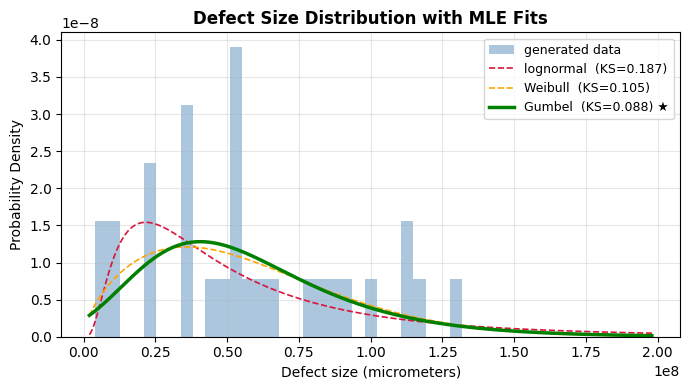

In [350]:
# plot histogram of defect sizes and overlay fitted PDFs
fig, ax = plt.subplots(figsize=(7, 4))

sizes_um = data * 1e6   # convert to micrometers for readability
ax.hist(sizes_um, bins=30, density=True, alpha=0.45,
        color="steelblue", label="generated data")

# overlay all three fitted PDFs
colors = {"lognormal": "crimson", "Weibull": "orange", "Gumbel": "green"}
x_m = np.linspace(data.min() * 0.5, data.max() * 1.5, 500)
x_um = x_m * 1e6

for name, (frozen, ks, p, _) in fit_results.items():
    pdf_vals = frozen.pdf(x_m) / 1e6   # Jacobian: dx_m = dx_um / 1e6
    lw = 2.5 if name == best_name else 1.2
    ls = "-" if name == best_name else "--"
    ax.plot(x_um, pdf_vals, color=colors[name], linewidth=lw, linestyle=ls,
            label=f"{name}  (KS={ks:.3f})" + (" ★" if name == best_name else ""))

# axes labels, title
ax.set_title("Defect Size Distribution with MLE Fits", fontweight="bold")
ax.set_xlabel("Defect size (micrometers)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("zhou_ti_graphs/2_defect_pdf.png", dpi=150)
plt.show()

**Gumbel** is the best fit for this data; whereas, it was assumed lognormal was the best when generating synthetic data.

# 3. Fatigue-Life Statistics
Experimental fatigue lives and defect measurements from Zhou et al. (2025) are analyzed using the Paris law and the Shiozawa framework and reliability methods.

The resulting distributions captures the scatter from defect variability.

## 3.1. Paris & Shiozawa Formulas
Integrating Paris law from a_0 to a_f with the Shiozawa approximation
(a_f >> a_i, so the a_f term → 0 for m > 2):

        N_f ≈ 2 / [(m-2) · C · (Y·delta_sigma)^m · pi^(m/2)] · a_i^(1 - m/2)

Re-written in terms of the initial SIF range deltaK_i = Y·delta_sigma·√(pi·a_i):

        N_f ≈ 2 / [(m-2) · C · pi · (Y·delta_sigma)^2] · deltaK_i^(2-m)

In [351]:
# define function based on Paris law
def fatigue_life_paris(sqrt_A, stress_a, C, m, Y, delta_sigma=None):

    # fully reversed (R = -1)
    if delta_sigma is None:
        delta_sigma = 2.0 * stress_a
    
    # constant of Paris/Shiozawa equation
    paris_coeff = 2.0 / ((m-2.0) * C * (Y * delta_sigma)**m * np.pi**(m/2))

    Nf = paris_coeff * sqrt_A**(1.0-(m/2.0))
    return Nf

def fatigue_life_paris_torch(sqrt_A, stress_a, C, m, Y, delta_sigma=None):

    # fully reversed loading, R = -1
    if delta_sigma is None:
        delta_sigma = 2.0 * stress_a

    # constant of Paris/Shiozawa equation
    paris_coeff = 2.0 / ((m-2.0) * C * (Y * delta_sigma)**m * torch.pi**(m / 2.0))

    Nf = paris_coeff * sqrt_A**(1.0 - (m / 2.0))
    return Nf

The **stress intensity factor, delta(K)**, the measure of the severity of a crack situation, is determined by

**delta(K) = Y * stress_amp * sqrt(pi * A)**

Assume the defect_size is the crack length: defect_size, A = crack_length, a

In [352]:
# define function to compute stress intensity factor, deltaK
def stress_intensity_factor(stress_a, defect_size):
    deltaK = Y * stress_a * np.sqrt(np.pi * defect_size)
    return deltaK

def stress_intensity_factor_torch(stress_a, defect_size):
    deltaK = Y * stress_a * torch.sqrt(torch.pi * defect_size)
    return deltaK

# define a function to compute the initial SIF range deltaK_i for a given initial crack size a_i
def delta_K_initial(sqrt_A, delta_sigma, Y):
    deltaK_i = Y * delta_sigma * np.sqrt(np.pi * sqrt_A)   # [MPa√m]
    return deltaK_i

## 3.2. Experimental Fatigue-Life Statistics


In [ ]:
dKi = delta_K_initial(sqrt_A_um, delta_sigma, Y)

Nnorm_samples = Nf / sqrt_A_m

# create one shared mask for valid rows (positive finite fatigue lives)
valid_mc = (
    np.isfinite(sqrt_A_um) &
    np.isfinite(Nf) & (Nf > 0) &
    np.isfinite(dKi) & (dKi > 0) &
    np.isfinite(Nnorm_samples) & (Nnorm_samples > 0)
    #np.isfinite(stress_min_valid) & (stress_min_valid > 0)
)

# apply the same mask to everything
#a0_valid = a_max[valid_mc]
Nf_samples_valid = Nf[valid_mc]
dKi_samples_valid = dKi[valid_mc]
Nnorm_samples_valid = Nnorm_samples[valid_mc]
#stress_min_valid = stress_min_valid[valid_mc]

### 3.2.a. Shiozawa Plot: deltaK_i vs N_f / √A
Expected slope from Paris law:
(N/√A) ∝ (deltaK_i)^(-m)
log(deltaK_i) = -(1/m)*log(N/√A) + C
→ **slope = -1/m**

In [354]:
# log-log linear fit
log_Nnorm = np.log10(Nnorm_samples_valid)   #.flatten()
log_dKi = np.log10(dKi_samples_valid)       #.flatten()

In [355]:
# fit line
slope, intercept = np.polyfit(log_Nnorm, log_dKi, 1)
a_fit = 10**intercept

# compare slope to expected from Paris law
expected_slope = -1.0 / m_Ti

# convert to numpy arrays
Nnorm_samples = np.asarray(Nnorm_samples, dtype=float)

N_norm_line = np.logspace(
    np.log10(Nnorm_samples.min()),
    np.log10(Nnorm_samples.max()),
    300
)
dK_line = a_fit * N_norm_line**slope

In [356]:
# convert data to tensors for plotting and PINN
a_tensor = torch.tensor(a0_valid, dtype=torch.float32).unsqueeze(1)           # input = max defect / initial crack size
Nf_tensor = torch.tensor(Nf_samples_valid, dtype=torch.float32).unsqueeze(1)  # output = fatigue life
stress_min_valid = torch.tensor(stress_min, dtype=torch.float32).unsqueeze(1)

Y_valid = torch.tensor(df["Y"].to_numpy(dtype=float)[valid_mc],
                       dtype=torch.float32).unsqueeze(1)
    #Y[valid_mc], dtype=torch.float32).unsqueeze(1)
stress_max_valid = torch.tensor(df["stress_max"].to_numpy(dtype=float)[valid_mc],
                                dtype=torch.float32).unsqueeze(1)

delta_sigma_valid = stress_max_valid - stress_min_valid
stress_a_valid = delta_sigma_valid / 2

Shiozawa log-log fit: slope = -0.2841
Expected from Paris (m=2.56492): slope = -0.3899


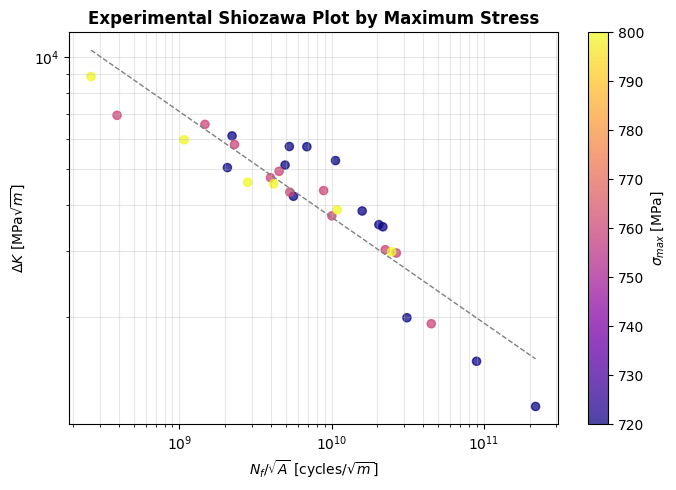

In [357]:
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(Nnorm_samples_valid, dKi_samples_valid,
    c=stress_max_valid.detach().numpy().squeeze(),
    cmap="plasma", alpha=0.75, s=35)

# show fitted line from log-log fit
ax.plot(N_norm_line, dK_line, color="grey", linewidth=1, linestyle="--",
        label=f"Fit: $\\Delta K_i$ = {a_fit:.2e}*(N/√A)^{slope:.3f}")

# log scale
ax.set_xscale("log")
ax.set_yscale("log")

# label, titles
ax.set_xlabel(r"$N_f/\sqrt{A}$ [cycles/$\sqrt{m}$]")
ax.set_ylabel(r"$\Delta K$ [MPa$\sqrt{m}$]")
ax.set_title(r"Experimental Shiozawa Plot by Maximum Stress",
             fontweight="bold")

# legend, colobar, grid
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\sigma_{max}$ [MPa]")
ax.grid(alpha=0.3, which="both")

print(f"Shiozawa log-log fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m_Ti}): slope = {expected_slope:.4f}")

# save and show
plt.tight_layout()
plt.savefig("zhou_ti_graphs/2_shiozawa_experimental_stress.png", dpi=150)
plt.show()

### 3.2.b. Reliability Curves

The fraction of specimens surviving beyond N cycles:

**R(N) = P(N_f > N)**

The Weibull model **R(N) = exp[-(N/η)^β]** is fitted for comparison

where:

- R(N) = reliability
- η = characteristic life
- β = Weibull shape parameter

Weibull: β = 1.684, η = 4.518e+05
  B10 (10% failure) = 1.187e+05 cycles
  B50 (50% failure) = 3.634e+05 cycles


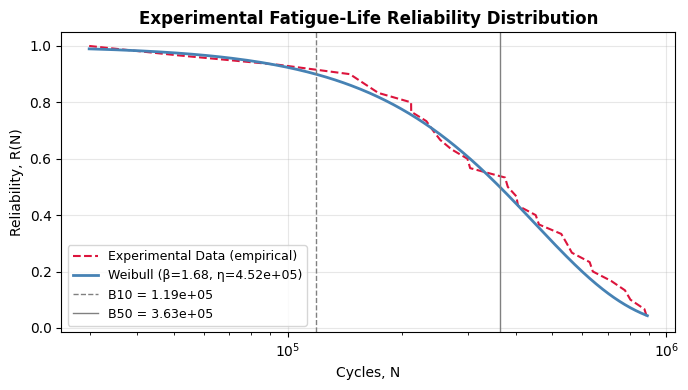

In [358]:
lives_sorted = np.sort(Nf_samples_valid)
R_empirical  = 1.0 - np.arange(len(lives_sorted)) / len(lives_sorted)

# Weibull MLE fit
shape_w, _, scale_w = weibull_min.fit(Nf_samples_valid, floc=0)
N_vals = np.linspace(lives_sorted.min(), lives_sorted.max(), 500)
R_weibull = np.exp(-(N_vals / scale_w)**shape_w)

# B10 and B50 lives
B10 = scale_w * (-np.log(0.90))**(1.0 / shape_w)        # 10% failure → R = 0.90
B50 = scale_w * (-np.log(0.50))**(1.0 / shape_w)        # 50% failure → R = 0.50
print(f"Weibull: β = {shape_w:.3f}, η = {scale_w:.3e}")
print(f"  B10 (10% failure) = {B10:.3e} cycles")
print(f"  B50 (50% failure) = {B50:.3e} cycles")

# plot reliability curves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lives_sorted, R_empirical, color="crimson", linewidth=1.5,
        linestyle="--", label="Experimental Data (empirical)")
ax.plot(N_vals, R_weibull, color="steelblue", linewidth=2,
        label=f"Weibull (β={shape_w:.2f}, η={scale_w:.2e})")

# show B10 and B50 as vertical lines
ax.axvline(B10, color="grey", linewidth=1, linestyle="--",
           label=f"B10 = {B10:.2e}")
ax.axvline(B50, color="grey", linewidth=1,
           label=f"B50 = {B50:.2e}")

# log scale for reliability plot
ax.set_xscale("log")

# axes labels, title
ax.set_title(f"Experimental Fatigue-Life Reliability Distribution",
             fontweight="bold")
ax.set_xlabel("Cycles, N")
ax.set_ylabel("Reliability, R(N)")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("zhou_ti_graphs/2_reliability.png", dpi=150)
plt.show()

### 3.2.c. S-N Curves
experimental S-N curves

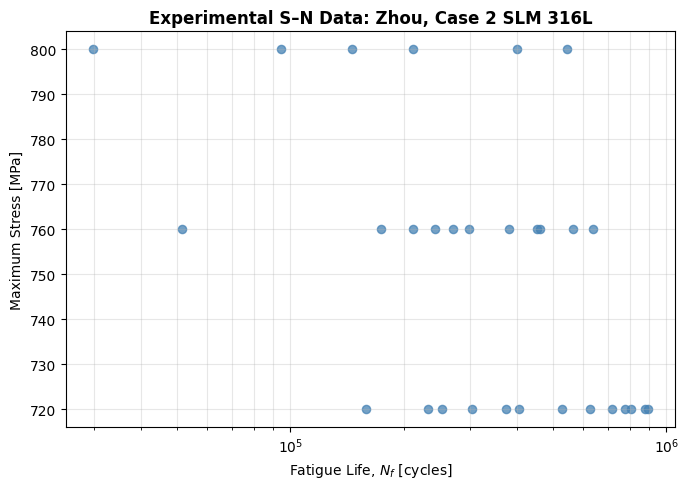

In [359]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(Nf_samples_valid,
           stress_max_valid.detach().numpy().squeeze(),
           color="steelblue", alpha=0.75, s=35,
           label="Experimental Data")

# log scale
ax.set_xscale("log")

# labels, title
ax.set_xlabel(r"Fatigue Life, $N_f$ [cycles]")
ax.set_ylabel(r"Maximum Stress [MPa]")
ax.set_title("Experimental S–N Data: Zhou, Case 2 SLM 316L",
             fontweight="bold")

# grid, legend
ax.grid(alpha=0.3, which="both")
#ax.legend()

# save and show
plt.tight_layout()
plt.savefig("zhou_ti_graphs/2_experimental_SN.png", dpi=150)
plt.show()

#### 3.2.c.i. PSN Curves
Binned percentiles are used to create a sort of probabilistic S-N curve.

In [360]:
stress_exp = stress_max_valid.detach().numpy().squeeze()
life_exp = Nf_samples_valid

# create stress bins to store fatigue life data
stress_bins = np.array([200, 250, 300, 350, 400, 450])

bin_centers = []
B10 = []
B50 = []
B90 = []

for i in range(len(stress_bins) - 1):
    mask = (stress_exp >= stress_bins[i]) & (stress_exp < stress_bins[i+1])
    lives_bin = life_exp[mask]

    if len(lives_bin) < 3:
        continue

    bin_centers.append(0.5 * (stress_bins[i] + stress_bins[i+1]))
    B10.append(np.quantile(lives_bin, 0.10))
    B50.append(np.quantile(lives_bin, 0.50))
    B90.append(np.quantile(lives_bin, 0.90))

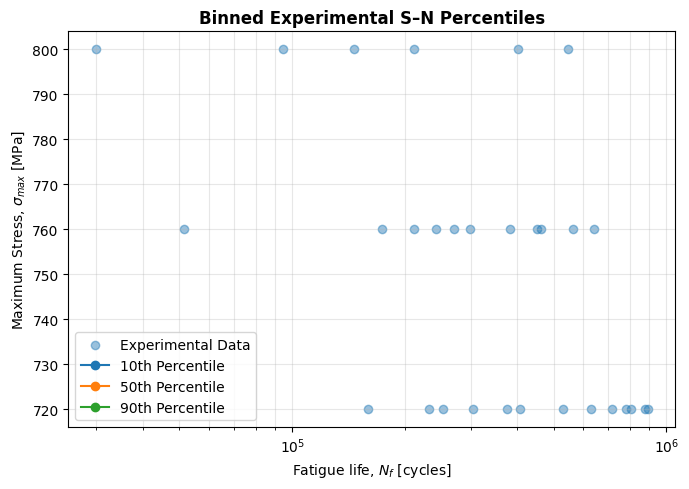

In [361]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(life_exp, stress_exp, alpha=0.45, label="Experimental Data")

# add probabilities of failure
ax.plot(B10, bin_centers, marker="o", label="10th Percentile")
ax.plot(B50, bin_centers, marker="o", label="50th Percentile")
ax.plot(B90, bin_centers, marker="o", label="90th Percentile")

# log scale
ax.set_xscale("log")

# labels, title
ax.set_xlabel(r"Fatigue life, $N_f$ [cycles]")
ax.set_ylabel(r"Maximum Stress, $\sigma_{max}$ [MPa]")
ax.set_title("Binned Experimental S–N Percentiles",
             fontweight="bold")

# legend, grid
ax.grid(alpha=0.3, which="both")
ax.legend()

# save and show
plt.tight_layout()
plt.savefig("zhou_ti_graphs/2_experimental_SN_percentiles.png", dpi=150)
plt.show()

# 4. PINN

In [362]:
# reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 4.1. Train/Test Split
Data is split into 70% training, 30% test as in Zhou et al. (2025).

In [363]:
n = a_tensor.shape[0]
#rng = torch.Generator().manual_seed(42)    # reproducible random split
perm = torch.randperm(n,
                      #generator=rng
                      )

n_train = int(0.70 * n)         # 70% training

train_idx = perm[:n_train]
test_idx = perm[n_train:]

# split physical tensors
a_train = a_tensor[train_idx]
a_test = a_tensor[test_idx]

Nf_train = Nf_tensor[train_idx]
Nf_test  = Nf_tensor[test_idx]

Y_train = Y_valid[train_idx]
Y_test = Y_valid[test_idx]

stress_a_train = stress_a_valid[train_idx]
stress_a_test = stress_a_valid[test_idx]

delta_sigma_train = delta_sigma_valid[train_idx]
delta_sigma_test = delta_sigma_valid[test_idx]

print(f"Total samples: {n}")
print(f"Train samples: {len(train_idx)}")
print(f"Test samples: {len(test_idx)}")

Total samples: 30
Train samples: 21
Test samples: 9


### 4.1.a. Define Data

In [364]:
# define data
X = [sqrt_A_um, stress_max, Y]
y = Nf

In [365]:
# build multi-input X
X_all = torch.cat([
    torch.log(a_tensor),
    torch.log(stress_max_valid),
    Y_valid
], dim=1)

y_all = torch.log(Nf_tensor)

# train/test split
X_train = X_all[train_idx]
X_test = X_all[test_idx]

y_train = y_all[train_idx]
y_test = y_all[test_idx]

# normalize from train only
X_mean = X_train.mean(dim=0, keepdim=True)
X_std = X_train.std(dim=0, keepdim=True)

# prevent divide-by-zero for constant columns like Y
X_std[X_std == 0] = 1.0

y_mean = y_train.mean()
y_std = y_train.std()

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

## 4.2. Define PINN

In [366]:
# define custom NN class
# lets PyTorch track parameters and gradients automatically
class PINN(nn.Module):
    def __init__(self): # initializes nn.Module
        super().__init__()
        self.net = nn.Sequential( # sequential container for layers, = feed-forward pipeline
            
            # first hidden layer
            nn.Linear(3, 64), # # (input (3), output)
            nn.Tanh(),
            
            # second hidden layer
            nn.Linear(64, 64),
            nn.Tanh(),

            # output = 1 number (N), since we want to predict a single fatigue life value for each input N/√A
            nn.Linear(64, 1) 
        )

    # forward method defines how input data flows through the network
    def forward(self, X):
        # log_Nf_scaled = self.net(X) # predicts scaled log(Nf)

        # # convert back to physical fatigue life
        # log_Nf = log_Nf_scaled * log_Nf_std + log_Nf_mean
        # Nf = torch.exp(log_Nf)        # makes prediction physical and positive
        
        # # predicts scaled log(Nf)
        return self.net(X)

PINN Architecture from Liao et al. (2025):
- 2 hidden layers 
- 64 neurons each 
- Tanh activation function

Liao et al. (2025). A physics-informed neural network method for identifying parameters and predicting remaining life of fatigue crack growth International. Journal of Fatigue, 191, 108678. https://doi.org/10.1016/j.ijfatigue.2024.108678.

### 4.2.a. Early Stopping
Implement **early stopping** on the model to monitor a **validation metric**, to monitor whether the model is still improving on the validation data on each epoch.

In [367]:
class EarlyStopping:
    def __init__(self, patience=500, min_delta=1e-6):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.best_state = None
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.early_stop = True

### 4.2.b. History Plots

In [368]:
# define a function to plot the history graphs
def plot_history(train_metric,
                 val_metric=None,
                 metric_name="Loss",
                 log_scale=False):
    
    fig, ax = plt.subplots(figsize=(7,4))

    ax.plot(train_metric, label=f"Train: {metric_name}")

    # validation metric
    if val_metric is not None:
        ax.plot(val_metric,
                 label=f"Val: {metric_name}")

    # axis labels
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric_name)
    ax.set_title(f"{metric_name} History", fontweight="bold")

    # log scale if necessayr
    if log_scale:
        ax.set_yscale("log")

    # legend, grig
    ax.legend()
    ax.grid(alpha=0.3)

    fig.tight_layout()
    
    # save and show
    filename = metric_name.lower().replace(" ", "_")
    fig.savefig(f"zhou_ti_graphs/3_val_{filename}.png", dpi=150)
    plt.show()

## 4.3. Define Losses
In general, **Total Loss = Data Loss + Physics Loss** where the losses are given by the **mean squared errors (MSE)**.

### 4.3.a. Physics Loss: Paris Law

In [369]:
# define a function to enforce the Paris Law
# everything in physics_loss must be torch operations to allow autograd to compute gradients
def physics_loss(model, X_scaled, a_physical, stress_a, C, m, Y, delta_sigma, y_mean, y_std):
    log_Nf_pred_scaled = model(X_scaled)
    log_Nf_pred = (log_Nf_pred_scaled * y_std + y_mean)

    Nf_physics = fatigue_life_paris_torch(a_physical, stress_a, C, m, Y, delta_sigma)

    # convert to log space
    log_Nf_physics = torch.log(Nf_physics)

    return torch.mean((log_Nf_pred - log_Nf_physics)**2)

### 4.3.b. Data Loss

In [370]:
# define a function to compute the data loss

# # log-MSE between predicted and true defect sizes
# def data_loss_logMSE(model, X_scaled, y_scaled):
#     y_pred_scaled = model(X_scaled)
#     return torch.mean((torch.log(y_pred_scaled) - torch.log(y_scaled))**2)

# MSE between predicted and true defect sizes
def data_loss_MSE(model, X_scaled, y_scaled):
    y_pred_scaled = model(X_scaled)
    return torch.mean((y_pred_scaled - y_scaled)**2)

Liao et al. (2025) uses 𝐿𝑜𝑠𝑠_𝐷 = 𝑀𝑆𝐸(𝑛_𝑝𝑟𝑒𝑑, 𝑛_𝑜𝑏𝑠) as the data loss function.

## 4.4. Training

In [371]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 5000
early_stopping = EarlyStopping(patience=1000, min_delta=1e-6)

loss_history = []
physics_loss_history = []
data_loss_history = []
val_loss_history = []
train_rmse_history = []
test_rmse_history = []

# weights
w_d_liao = 100.0    # weight for data loss, from Liao et al. (2025)
w_p_liao = 1.0      # weight for physics loss, from Liao et al. (2025)
w_d = 1.0           # weight for data loss
w_p = 0.001          # weight for physics loss

# train for many iterations (epochs)
for epoch in range(epochs):
    
    # training
    model.train()
    optimizer.zero_grad()       # reset gradients before backprop

    y_pred_train = model(X_train_scaled)

    # define losses
    loss_d = data_loss_MSE(model, X_train_scaled, y_train_scaled)
    loss_p = physics_loss(model, X_train_scaled, a_train,
                          stress_a_train, C_Ti, m_Ti, Y_train,
                          delta_sigma_train, y_mean, y_std)

    # weighted total loss
    loss = (w_d_liao * loss_d) + (w_p_liao * loss_p)

    loss.backward()             # backpropagation: computes gradients of all parameters
    optimizer.step()            # updates network weights

    # validation / test loss
    model.eval()
    with torch.no_grad():
        val_data_loss = data_loss_MSE(model, X_test_scaled, y_test_scaled)

        train_pred = model(X_train_scaled)
        train_rmse = torch.sqrt(torch.mean((train_pred - y_train_scaled)**2))

        test_pred = model(X_test_scaled)
        test_rmse = torch.sqrt(
        torch.mean((test_pred - y_test_scaled)**2))

    # early stopping checks validation data loss
    early_stopping(val_data_loss.item(), model)

    # save histories
    loss_history.append(loss.item())
    physics_loss_history.append(loss_p.item())
    data_loss_history.append(loss_d.item())
    train_rmse_history.append(train_rmse.item())
    test_rmse_history.append(test_rmse.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total: {loss.item():.4e} | "
            f"Data: {loss_d.item():.4e} | "
            f"Physics: {loss_p.item():.4e} | "
            f"Val: {val_data_loss.item():.4e}"
        )

    if early_stopping.early_stop:
        print(f"Early stopping at epoch {epoch}")
        break

# restore best validation model
if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)

Epoch     0 | Total: 1.2266e+02 | Data: 8.9822e-01 | Physics: 3.2840e+01 | Val: 5.3471e-01
Epoch   500 | Total: 4.0983e+01 | Data: 7.6467e-02 | Physics: 3.3336e+01 | Val: 3.4255e-01
Epoch  1000 | Total: 3.3703e+01 | Data: 2.9758e-03 | Physics: 3.3405e+01 | Val: 4.2095e-01
Early stopping at epoch 1076


*For weights (lambda_d = 100, lambda_p = 1), of first implementation*: Liao et al. (2025).

### 4.4.a. Plot Accuracy
use RMSE history to show accuracy

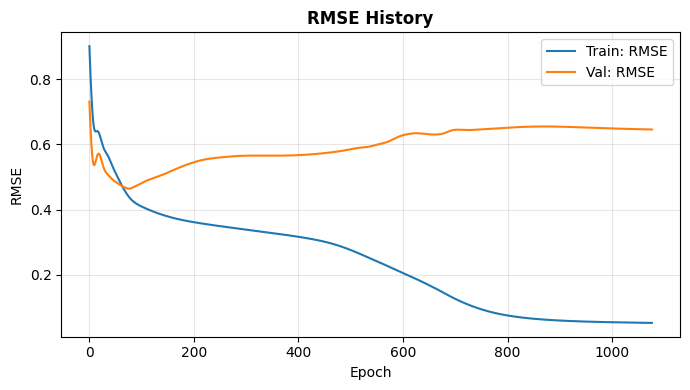

In [372]:
plot_history(train_metric=train_rmse_history,
             val_metric=test_rmse_history,
             metric_name="RMSE",
             log_scale=False)

The **training RMSE** drops from about 0.9 to 0.05, which is great.

The **validation RMSE** drops initially, then increases, then plateaus around 0.64. This indicates **overfitting**: The model keeps getting better at training data while getting worse on unseen data.

The validation minimum is around 50-100 epochs, then trining improves and validation worsen, so the network is **memorizing**.

## 4.5. Predictions

In [373]:
model.eval()

with torch.no_grad():
    y_pred_train_scaled = model(X_train_scaled)
    y_pred_test_scaled  = model(X_test_scaled)

    # unscale back to log(Nf)
    log_Nf_pred_train = y_pred_train_scaled * y_std + y_mean
    log_Nf_pred_test  = y_pred_test_scaled  * y_std + y_mean

    # convert log(Nf) back to physical cycles
    Nf_pred_train = torch.exp(log_Nf_pred_train).numpy()
    Nf_pred_test  = torch.exp(log_Nf_pred_test).numpy()

a_np = a_tensor.numpy()
Nf_train_np = Nf_train.numpy()
Nf_test_np  = Nf_test.numpy()

# # sort for plotting
# sort_idx = np.argsort(a_np)
# a_sorted = a_np[sort_idx]
# Nf_train_sorted = Nf_train_np[sort_idx]
# Nf_test_sorted = Nf_test_np[sort_idx]

### 4.5.a. Evaluation

In [374]:
# prediction errors
errors_test = Nf_pred_test - Nf_test_np

mse_test = np.mean(errors_test**2)        # mean squared error
rmse_test = np.sqrt(mse_test)             # root mean squared error
mae_test = np.mean(np.abs(errors_test))   # mean absolute error

# log-space errors
log_errors_test = np.log(Nf_pred_test) - np.log(Nf_test_np)

log_mse_test = np.mean(log_errors_test**2)
log_rmse_test = np.sqrt(log_mse_test)
log_mae_test = np.mean(np.abs(log_errors_test))

# print results table
print(f"{'Metric':<10} {'Value':>14} {'Log Value':>14}")
print("-" * 42)

print(f"{'MSE':<10} {mse_test:>14.4e} {log_mse_test:>14.4e}")
print(f"{'RMSE':<10} {rmse_test:>14.4e} {log_rmse_test:>14.4e}")
print(f"{'MAE':<10} {mae_test:>14.4e} {log_mae_test:>14.4e}")

Metric              Value      Log Value
------------------------------------------
MSE            2.1806e+10     1.6414e-01
RMSE           1.4767e+05     4.0514e-01
MAE            1.2225e+05     3.1633e-01


### 4.5.b. Accuracy Plots

#### 4.5.b.i. Training History Plots

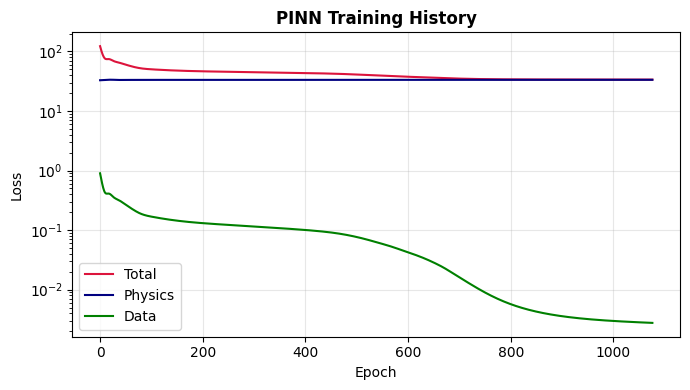

In [375]:
# plot training history
fig, ax = plt.subplots(figsize=(7,4))

ax.plot(loss_history, color="crimson", label="Total")
ax.plot(physics_loss_history, color="navy", label="Physics")
ax.plot(data_loss_history, color="green", label="Data")

# log scale
ax.set_yscale("log")

# axes labels, title
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("PINN Training History", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
plt.tight_layout()
plt.savefig("zhou_ti_graphs/3_PINN_loss_history.png", dpi=150)
plt.show()

**Results with w_d = 1.0, w_p = 0.001:**

The **data loss** decreases from 1.0 to 0.002, which is very good.

The **physics loss** stays roughly constant, which is not good.

So, the network is fitting the data, but not reducing the Paris-law residual. This is effectively an ANN with a constant penalty.

The **physics loss** is constant because:
- the data does not really fit the Paris law well
- the *C* and *m* for each sample may be completely different
- the physics loss >> the data loss
- the network may be finding the best fit to data and best fit to physics in different regions

**Results with w_d_liao = 100.0, w_p_liao = 1.0:**

The **data loss** decreases from 0.9 to 0.003, which is good.

The **physics loss** is essentially constant at about 30. So, loss_p is not being reduced. It is still behaving line a traditional ANN.

#### 4.4.b.ii. Predicted vs. True Defect Sizes

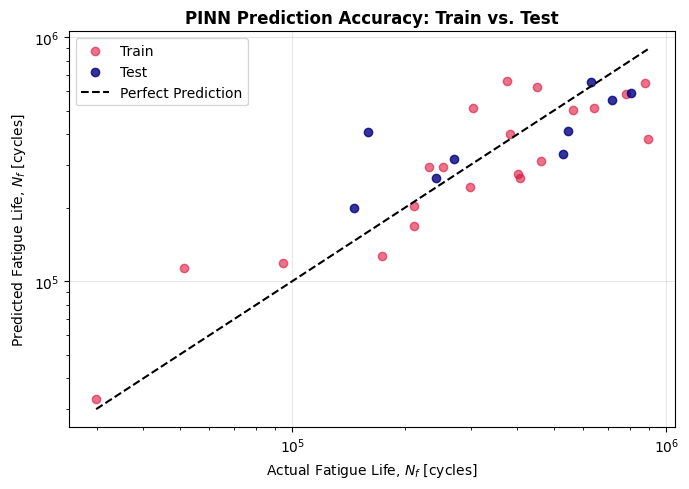

In [376]:
# plot predicted vs. true defect sizes
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(Nf_train_np, Nf_pred_train,
           color="crimson",
           alpha=0.6, label="Train")
ax.scatter(Nf_test_np, Nf_pred_test,
           color="navy",
           alpha=0.8, label="Test")

min_val = min(Nf_train_np.min(), Nf_test_np.min(), Nf_pred_train.min(), Nf_pred_test.min())
max_val = max(Nf_train_np.max(), Nf_test_np.max(), Nf_pred_train.max(), Nf_pred_test.max())

ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", label="Perfect Prediction")

# log-log scale
ax.set_xscale("log")
ax.set_yscale("log")

# axes labels, title
ax.set_xlabel(r"Actual Fatigue Life, $N_f$ [cycles]")
ax.set_ylabel(r"Predicted Fatigue Life, $N_f$ [cycles]")
ax.set_title("PINN Prediction Accuracy: Train vs. Test", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
fig.tight_layout()
fig.savefig("zhou_ti_graphs/3_PINN_accuracy_train_vs_test.png", dpi=150)
plt.show()

**Results with w_d = 1.0, w_p = 0.001:**

Good:
- no crazy failures
- no obvious separation b/w the train and test sets

Bad:
- The test points are compressed, so the model has learned the trend but not the variability.

**Results with w_d_liao = 100.0, w_p_liao = 1.0:**

Good:
- train and test points overlap reasonably well.
- no obvious train/test separation
- no catastrophic failures
- predictions stay within the correct order of magnitude
- test points follow the same trend as training points

This indicates the model is **generalizing** rather than memorizing.

Bad:
- the predictions are compressed toward the middle:
    - low-life specimens are overpredicted
    - high-life specimens are underpredicted

This suggests regression-to-the-mean behavior; the network struggles to reproduce the full scatter. This is consistent with the validation RMSE curve.

### 4.5.c. Crack Growth Curve
Plot fatigue life vs. initial defect size for train and test data

In [377]:
# convert tensors to 1D numpy arrays
a_train_np = a_train.detach().cpu().numpy().squeeze()
a_test_np  = a_test.detach().cpu().numpy().squeeze()

Nf_train_np = Nf_train.detach().cpu().numpy().squeeze()
Nf_test_np  = Nf_test.detach().cpu().numpy().squeeze()

Nf_pred_train_np = Nf_pred_train.squeeze()
Nf_pred_test_np  = Nf_pred_test.squeeze()

# sort train data by crack size
train_sort_idx = np.argsort(a_train_np)
a_train_sorted = a_train_np[train_sort_idx]
Nf_train_sorted = Nf_train_np[train_sort_idx]
Nf_pred_train_sorted = Nf_pred_train_np[train_sort_idx]

# sort test data by crack size
test_sort_idx = np.argsort(a_test_np)
a_test_sorted = a_test_np[test_sort_idx]
Nf_test_sorted = Nf_test_np[test_sort_idx]
Nf_pred_test_sorted = Nf_pred_test_np[test_sort_idx]

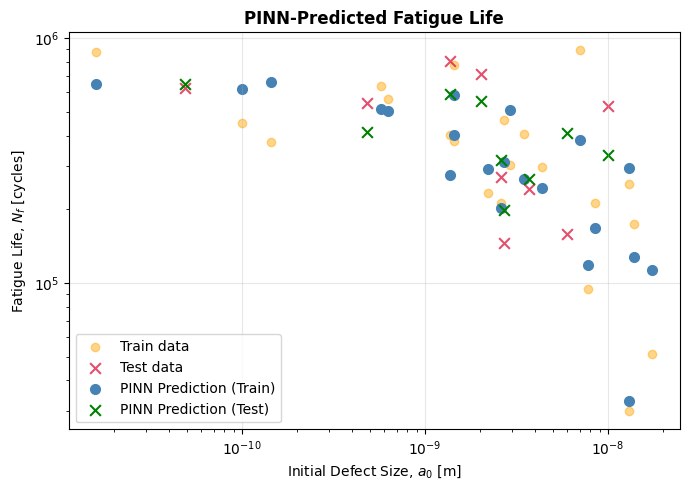

In [378]:
fig, ax = plt.subplots(figsize=(7, 5))

# true experimental data
ax.scatter(a_train_sorted, Nf_train_sorted,
           color="orange",
           alpha=0.45, label="Train data")

ax.scatter(a_test_sorted, Nf_test_sorted,
           color="crimson", marker="x", s=60,
           alpha=0.75, label="Test data")

# model predictions
ax.scatter(a_train_sorted, Nf_pred_train_sorted,
           color="steelblue",
           linewidth=2, label="PINN Prediction (Train)")

ax.scatter(a_test_sorted, Nf_pred_test_sorted,
           color="green", marker="x", 
           s=60, label="PINN Prediction (Test)")

# log-log scale
ax.set_xscale("log")
ax.set_yscale("log")

# labels, title
ax.set_xlabel(r"Initial Defect Size, $a_0$ [m]")
ax.set_ylabel(r"Fatigue Life, $N_f$ [cycles]")
ax.set_title("PINN-Predicted Fatigue Life", fontweight="bold")

# legend, grid
ax.grid(alpha=0.3)
ax.legend()

# save and show
fig.tight_layout()
fig.savefig("zhou_ti_graphs/3_PINN_life_vs_defect.png", dpi=150)
plt.show()

# 5. Appendix

## 5.1. Process Parameters & VED
laser power, scan speed, hatch spacing, layer thickness

The Volumetric Energy Density (VED) is the laser energy input per unit volume of material:

**VED = P / (vht)**

where
- power, P, [W] = [J/s]
- scan velocity, v, [mm/s]
- layer thickness, t, [mm]
- hatch spacing, h, [mm]

and
- low VED → lack-of-fusion porosity
- high VED → keyhole porosity
- both increase defect density

In [379]:
# define dictionary of process parameters
process_params = {
    "Case 2 SLM 316l": {
        "As-printed-1": {"P": 250, "v": 850, "h": 0.12, "t": 0.05},
        "As-printed-2": {"P": 300, "v": 1126, "h": 0.14, "t": 0.05},
        "Deep cryogenic treatment": {"P": 250, "v": 850, "h": 0.12, "t": 0.05},
    }
}

Values are given in Zhou et al. (2025), but the batch/processing condition is not given in the dataset, so the parameters cannot be assigned.

In [380]:
# volumetric energy density
VED_op = P / (v * h * t)

print(f"P = {P} W,  v = {v} mm/s,  h = {h} mm,  t = {t} mm")
print(f"VED_op = {VED_op:.2f} J/mm^3")

NameError: name 'P' is not defined

*For energy densities and parameters:*
Sola, A., Nouri, A., Peyre, P., Ghodbane, J., Sanz, C., Morville, S., Hueso, J., & Aubry, P. (2021). Processability of pure copper by laser powder bed fusion and its potential applications. Additive Manufacturing, 47, 102340. <https://www.sciencedirect.com/science/article/pii/S2214860420309246#tbl0005>. 

*More data:*
van der Linde, C., Sideris, I., Deillon, L., Afrasiabi, M., & Bambach, M. (2026). Microstructure engineering of Ti-6Al-4V in laser powder bed fusion via 1D thermal modeling and supporting experiments. arXiv:2604.24669.
https://arxiv.org/html/2604.24669v1 

## 5.1.a. VED
An **empirical approximation** curve relates VED to relative density. This relationship should be treated as illustrative.

*For relative densities and optimal VED values:*
Bittner, F., Müller, B., & Thielsch, J. (2022). Efficient LPBF-process development by Design of Experiments. Fraunhofer Institute for Machine Tools and Forming Technology (IWU), Dresden, Germany. <https://publica-rest.fraunhofer.de/server/api/core/bitstreams/5db78b1a-ed75-4d57-aa78-b5712aae8a45/content>. 

*For relative density values and expected relative density vs. VED curve:*
Park, H. et al. (2024). Relationship between volumetric energy density and relative density in laser powder bed fusion additive manufacturing: A review and analysis. Journal of Powder Materials, 2024. <https://www.powdermat.org/journal/view.php?doi=10.4150/jpm.2024.00038>.

**VALUES NEED TO BE UPDATED**

In [ ]:
# define VED-relative density relationship parameters
VED_opt = 81.0        # optimal VED

rd_min = 0.865        # min relative density (normalized to 1 at optimal VED)
rd_max = 0.99992      # max relative density (normalized to 1 at optimal VED)

k = 0.05              # steepness of VED curve

## 5.2. Max.-Defect Distribution
The maximum defect is given in the data by √A. Since this is the data reported by Zhou, this data was already fitted as a PDF in section 2.2. For the sake of thoroughness, it is shown.

### 5.2.a. Generalized Extreme Value Distribution (GEV)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

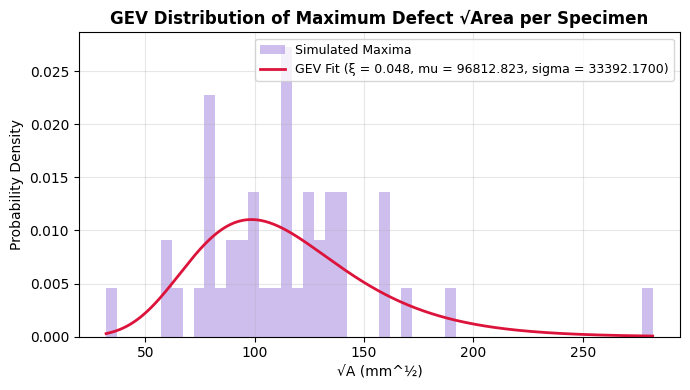

In [ ]:
# GEV fit to per-specimen maximum defect sizes
        # gev_c = shape parameter (ξ)
        # gev_loc = location parameter (mu)
        # gev_scale = scale parameter (sigma)
gev_c, gev_loc, gev_scale = genextreme.fit(sqrt_A_um)

x_gev = np.linspace(sqrt_A_um.min(), sqrt_A_um.max(), 500)
pdf_gev = genextreme.pdf(x_gev, gev_c, gev_loc, gev_scale)

# convert [sqrt(m)] to [sqrt(mm)]
# conv = np.sqrt(1000)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(sqrt_A_um,
        bins=50,
        density=True,
        alpha=0.45,
        color="mediumpurple",
        label="Simulated Maxima")

ax.plot(x_gev,
        pdf_gev,
        color="crimson",
        linewidth=2,
        label=f"GEV Fit (ξ = {gev_c:.3f}, mu = {gev_loc*1e3:.3f}, sigma = {gev_scale*1e3:.4f})")

# axes labels, title
ax.set_title("GEV Distribution of Maximum Defect √Area per Specimen", fontweight="bold")
ax.set_xlabel("√A (mm^½)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("zhou_ti_graphs/A_GEV.png", dpi=150)
plt.show()

## 5.3. Shiozawa Curves for Varying Stress Amps.

Each stress level produces a shifted band on the **deltaK_i vs N_f/√A** plot.

With Paris law physics, these bands should **collapse onto a single trendline** when the Murakami normalization is applied, thus confirming the consistency of the framework.

Shiozawa collapse fit: slope = -0.4232
Expected from Paris (m=2.56492): slope = -0.1667


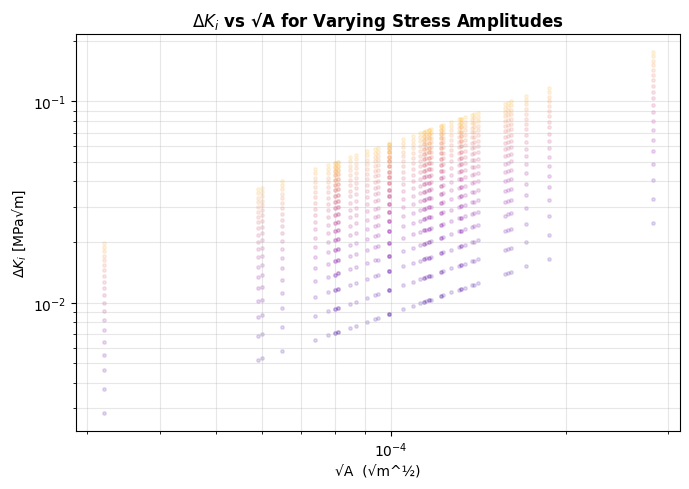

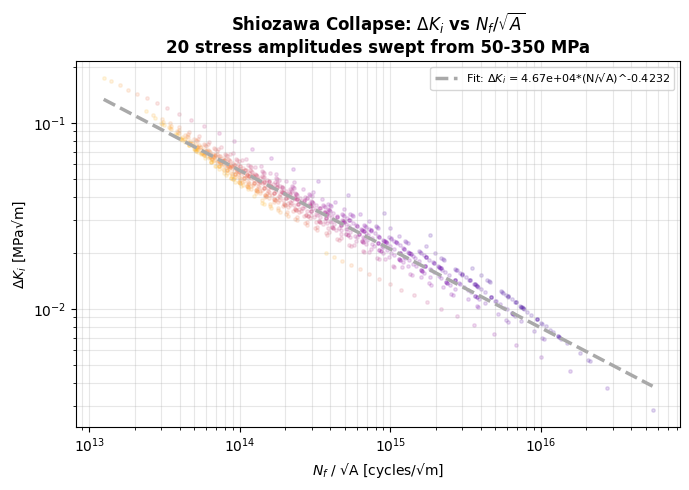

In [ ]:
S_vals = np.linspace(50, 350, 20)     # stress amplitudes to sweep [MPa]

# empty lists to store info
dKi_all = []
Nnorm_all = []

# create subplots for deltaK_i vs √A and deltaK_i vs N/√A
fig1, ax1 = plt.subplots(figsize=(7, 5))    # deltaK_i vs √A
fig2, ax2 = plt.subplots(figsize=(7, 5))    # deltaK_i vs N/√A  (Shiozawa collapse)

colors_s = plt.cm.plasma(np.linspace(0.1, 0.85, len(S_vals)))

for Si, ci in zip(S_vals, colors_s):
    ds_i = 2.0 * Si                       # delta_sigma for R = -1
    
    Nf_i = fatigue_life_paris(sqrt_A_um, Si, C, m, Y, delta_sigma=ds_i)
    dKi_i = delta_K_initial(sqrt_A_um, ds_i, Y)
    sqrt_A_i = sqrt_A_um

    Nnorm_i = (Nf_i / sqrt_A_i)           # normalized life, N/√A [cycles/√m]
    
    # store results
    dKi_all.append(dKi_i)
    Nnorm_all.append(Nnorm_i)

    # plots
    ax1.scatter(sqrt_A_i, dKi_i, alpha=0.15, s=6, color=ci,
                #label=f"S = {Si} MPa"
                )
    ax2.scatter(Nnorm_i, dKi_i, alpha=0.15, s=6, color=ci,
                #label=f"S = {Si} MPa"
                )

all_dKi = np.concatenate(dKi_all) 
all_Nnorm = np.concatenate(Nnorm_all)

log_x = np.log10(all_Nnorm)
log_y = np.log10(all_dKi)

slope, intercept = np.polyfit(log_x, log_y, 1)

x_line = np.logspace(log_x.min(), log_x.max(), 300)
y_line = 10**intercept * x_line**slope

print(f"Shiozawa collapse fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m}): slope = {expected_slope:.4f}")

# show fitted line from log-log fit on shiozawa collapse plot
ax2.plot(x_line, y_line, color="darkgray", linewidth=2.5, linestyle="--",
         label=f"Fit: $\\Delta K_i$ = {10**intercept:.2e}*(N/√A)^{slope:.4f}")

for ax, xlabel, title in [
    # x-axis label, title for each plot
    (ax1, "√A  (√m^½)",
     "$\\Delta K_i$ vs √A for Varying Stress Amplitudes"),
    (ax2, "$N_f$ / √A [cycles/√m]",
     "Shiozawa Collapse: $\\Delta K_i$ vs $N_f/\\sqrt{A}$\n"
     "20 stress amplitudes swept from 50-350 MPa"),
]:

    # log-log scale for both plots
    ax.set_xscale("log")
    ax.set_yscale("log")

    # axes labels, titles for both plots
    ax.set_xlabel(xlabel)
    ax.set_ylabel("$\\Delta K_i$ [MPa√m]")
    ax.set_title(title, fontweight="bold")
    
    # legends, grids
    ax.grid(alpha=0.3, which="both")

ax2.legend(fontsize=8, ncol=2, #title="Stress Amplitude"
           )
# save and show
fig1.tight_layout(); fig1.savefig("zhou_ti_graphs/A_shiozawa_dK_sqrtA.png", dpi=150)
fig2.tight_layout(); fig2.savefig("zhou_ti_graphs/A_shiozawa_collapse.png",  dpi=150)
plt.show()

Across a dense sweep of stress amplitudes, the Shiozawa collapse is visible.